# 05. Signal Retention Analysis

이번 단계에서는 이전 단계에서 정의한

- 기준 입력 신호 $x(s)$
- 잡음 $n(s)$
- 시간에 따른 결합 계수 $h(t)$

를 하나의 모델로 결합한다.

증폭 이득은 우선

$$
g=1
$$

로 고정하고 관측 신호를

$$
y(t,s)=h(t)x(s)+n(s)
$$

로 정의한다.

동일한 손상 조건에서

1. 회복이 없는 경우
2. 생물학적 회복을 가정한 경우

를 비교하여 신호 RMS와 SNR이 시간에 따라 얼마나
유지되거나 회복되는지 정량적으로 평가한다.

현재의 회복식과 파라미터는 실제 생물학적 측정값이 아니라
가설 모델을 검토하기 위한 정규화된 값이다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#기준 신호 x(s) 다시생성
SEED = 42
rng = np.random.default_rng(SEED)

n_samples = 512
s = np.arange(n_samples) / n_samples

x = (
    np.sin(2 * np.pi * 7 * s)
    + 0.35 * np.sin(2 * np.pi * 19 * s)
)

x = x - x.mean()
x = x / np.sqrt(np.mean(x**2))

sigma = 0.2

noise = rng.normal(
    loc=0.0,
    scale=sigma,
    size=n_samples
)

In [3]:
print(f"Input RMS = {np.sqrt(np.mean(x**2)):.3f}")
print(f"Noise RMS = {np.sqrt(np.mean(noise**2)):.3f}")

Input RMS = 1.000
Noise RMS = 0.194


In [4]:
#04에서 만든 coupling() 다시사용
def coupling(
        t,
        damage = 0.5,
        repair_rate = 0.3,
        repair_delay = 2.0,
        damage_time = 3.0,
        h_max = 1.0
):
    t = np.asarray(t, dtype=float)

    assert 0 <= damage < 1
    assert repair_rate >= 0
    assert repair_delay >= 0

    h_initial = 1.0 - damage

    assert h_initial <= h_max <= 1.0

    elapsed = np.maximum(
        t - damage_time - repair_delay,
        0.0
    )

    repaired = (
        h_initial
        + (h_max - h_initial)
        * (1 - np.exp(-repair_rate * elapsed))
    )

    return np.where(
        t < damage_time,
        1.0,
        repaired
    )

In [7]:
#느린 시간축 & 파라미터 설정
dt_slow = 0.05

t = np.arange(
    0,
    30.0 + dt_slow / 2,
    dt_slow
)

damage_time = 3.0
damage = 0.5

repair_rate = 0.3
repair_delay = 2.0
h_max = 1.0

In [9]:
#회복없는조건
h_no_repair = np.where(
    t < damage_time,
    1.0,
    1.0 - damage
)

In [12]:
#회복있는조건
h_repair = coupling(
    t,
    damage=damage,
    repair_rate=repair_rate,
    repair_delay=repair_delay,
    damage_time=damage_time,
    h_max=h_max
)

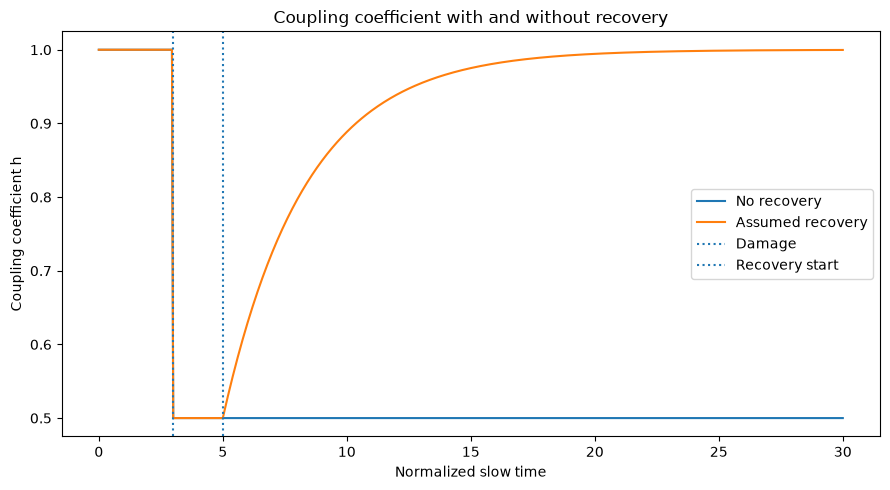

In [14]:
#h(t) 확인
plt.figure(figsize=(9, 5))

plt.plot(
    t,
    h_no_repair,
    label="No recovery"
)

plt.plot(
    t,
    h_repair,
    label="Assumed recovery"
)

plt.axvline(
    damage_time,
    linestyle=":",
    label="Damage"
)

plt.axvline(
    damage_time + repair_delay,
    linestyle=":",
    label="Recovery start"
)

plt.xlabel("Normalized slow time")
plt.ylabel("Coupling coefficient h")

plt.title(
    "Coupling coefficient with and without recovery"
)

plt.legend()

plt.tight_layout()
plt.show()

In [15]:
#h(t)x(s)

clean_no_repair = (
    h_no_repair[:, None]
    * x[None, :]
)

clean_repair = (
    h_repair[:, None]
    * x[None, :]
)

In [ ]:
#NumPy broadcasting 확인해보기

print("h shape:")
print(h_repair.shape)

print()

print("h[:, None] shape:")
print(h_repair[:, None].shape)

print()

print("x shape:")
print(x.shape)

print()

print("x[None, :] shape:")
print(x[None, :].shape)

print()

print("clean signal shape:")
print(clean_repair.shape)

h shape:
(601,)

h[:, None] shape:
(601, 1)

x shape:
(512,)

x[None, :] shape:
(1, 512)

clean signal shape:
(601, 512)


In [19]:
# 잡음 더해서 실제 관측 신호만들기

y_no_repair = (
    clean_no_repair
    + noise[None, :]
)

y_repair = (
    clean_repair
    + noise[None, :]
)

In [20]:
#특정시간 waveform 비교

snapshot_time = 7.0

j = np.argmin(
    np.abs(t - snapshot_time)
)

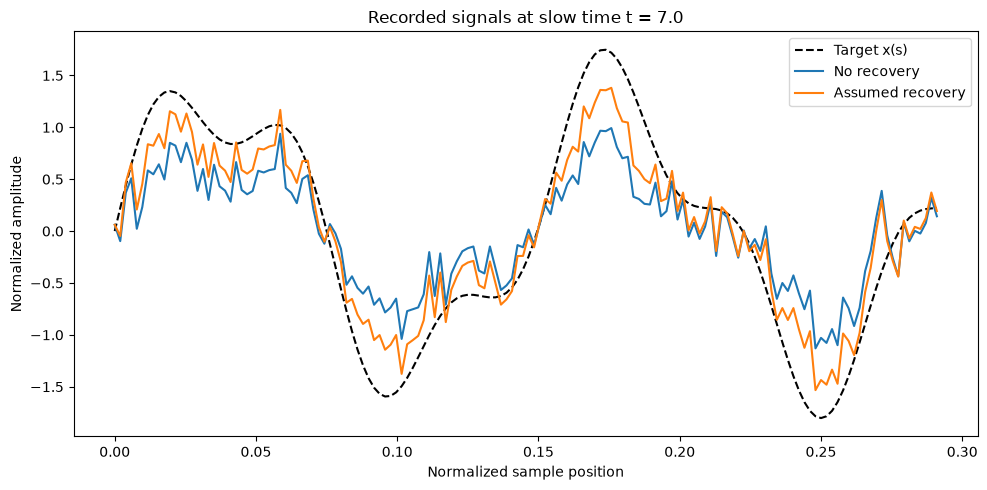

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    s[:150],
    x[:150],
    "k--",
    label="Target x(s)"
)

plt.plot(
    s[:150],
    y_no_repair[j, :150],
    label="No recovery"
)

plt.plot(
    s[:150],
    y_repair[j, :150],
    label="Assumed recovery"
)

plt.xlabel("Normalized sample position")
plt.ylabel("Normalized amplitude")

plt.title(
    f"Recorded signals at slow time t = {t[j]:.1f}"
)

plt.legend()

plt.tight_layout()
plt.show()

In [22]:
#Clean signal RMS 계산
rms_no_repair = np.sqrt(
    np.mean(
        clean_no_repair ** 2,
        axis = 1
    )
)

rms_repair = np.sqrt(
    np.mean(
        clean_repair ** 2,
        axis = 1
    )
)

In [23]:
assert np.allclose(
    rms_no_repair,
    h_no_repair
)

assert np.allclose(
    rms_repair,
    h_repair
)

print(
    "Clean signal RMS matches coupling coefficient h."
)

Clean signal RMS matches coupling coefficient h.


In [24]:
#Signal Retention Ratio 정의

baseline_rms = 1.0

srr_no_repair = (
    rms_no_repair / baseline_rms
)

srr_repair = (
    rms_repair / baseline_rms
)

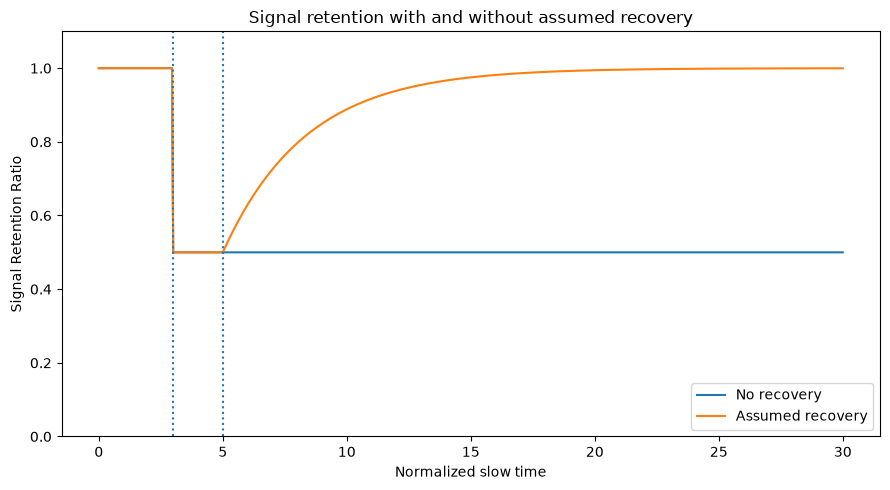

In [25]:
#Signal Retention 그래프
plt.figure(figsize=(9, 5))

plt.plot(
    t,
    srr_no_repair,
    label="No recovery"
)

plt.plot(
    t,
    srr_repair,
    label="Assumed recovery"
)

plt.axvline(
    damage_time,
    linestyle=":"
)

plt.axvline(
    damage_time + repair_delay,
    linestyle=":"
)

plt.xlabel("Normalized slow time")
plt.ylabel("Signal Retention Ratio")

plt.title(
    "Signal retention with and without assumed recovery"
)

plt.ylim(0, 1.1)

plt.legend()

plt.tight_layout()
plt.show()

In [26]:
#SNR 계산

noise_rms = np.sqrt(
    np.mean(noise**2)
)

In [27]:
snr_no_repair = (
    20
    * np.log10(
        rms_no_repair / noise_rms
    )
)

snr_repair = (
    20
    * np.log10(
        rms_repair / noise_rms
    )
)

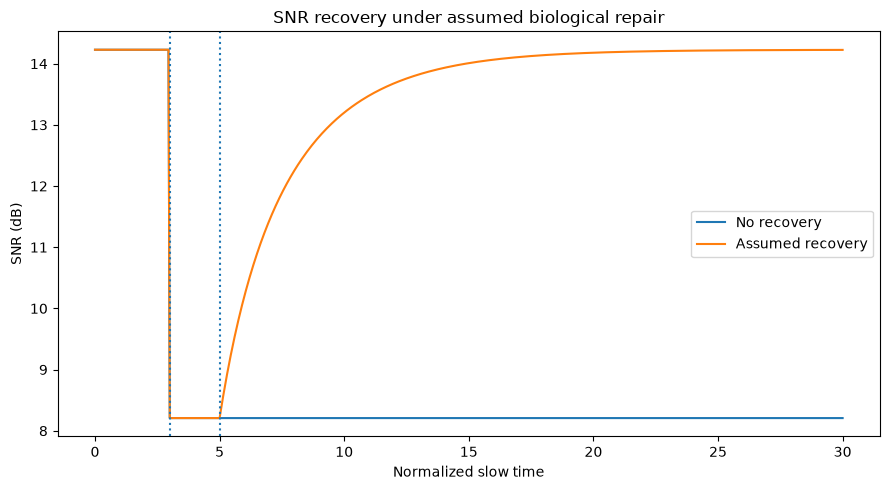

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    t,
    snr_no_repair,
    label="No recovery"
)

plt.plot(
    t,
    snr_repair,
    label="Assumed recovery"
)

plt.axvline(
    damage_time,
    linestyle=":"
)

plt.axvline(
    damage_time + repair_delay,
    linestyle=":"
)

plt.xlabel("Normalized slow time")
plt.ylabel("SNR (dB)")

plt.title(
    "SNR recovery under assumed biological repair"
)

plt.legend()

plt.tight_layout()
plt.show()

In [29]:
#"회복이 없을 때에 비해 얼마나 좋아졌는가?"에 대해 계산

check_time = 10.0

j = np.argmin(
    np.abs(t - check_time)
)

print(
    f"Slow time = {t[j]:.2f}"
)

print(
    f"No recovery h       = {h_no_repair[j]:.3f}"
)

print(
    f"Assumed recovery h  = {h_repair[j]:.3f}"
)

print(
    f"No recovery SNR     = {snr_no_repair[j]:.2f} dB"
)

print(
    f"Recovery SNR        = {snr_repair[j]:.2f} dB"
)

Slow time = 10.00
No recovery h       = 0.500
Assumed recovery h  = 0.888
No recovery SNR     = 8.21 dB
Recovery SNR        = 13.20 dB


In [30]:
#improvement

retention_improvement = (
    srr_repair[j]
    - srr_no_repair[j]
)

snr_improvement = (
    snr_repair[j]
    - snr_no_repair[j]
)

print(
    f"Retention improvement = "
    f"{retention_improvement:.3f}"
)

print(
    f"SNR improvement = "
    f"{snr_improvement:.2f} dB"
)

Retention improvement = 0.388
SNR improvement = 4.99 dB


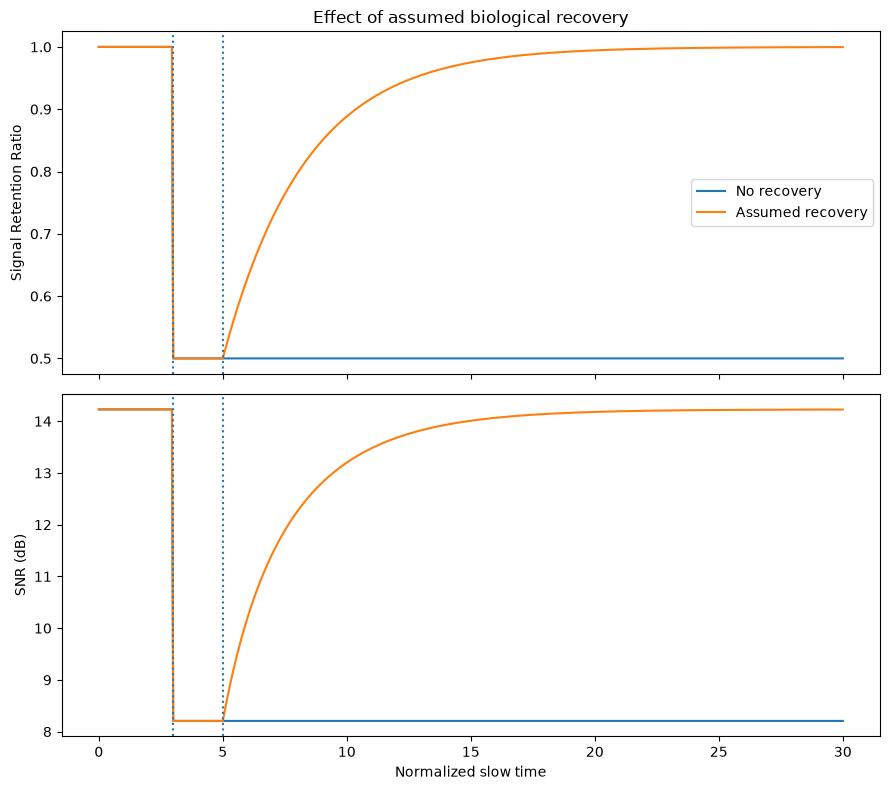

In [31]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True
)

axes[0].plot(
    t,
    srr_no_repair,
    label="No recovery"
)

axes[0].plot(
    t,
    srr_repair,
    label="Assumed recovery"
)

axes[0].set_ylabel(
    "Signal Retention Ratio"
)

axes[0].set_title(
    "Effect of assumed biological recovery"
)

axes[0].legend()


axes[1].plot(
    t,
    snr_no_repair,
    label="No recovery"
)

axes[1].plot(
    t,
    snr_repair,
    label="Assumed recovery"
)

axes[1].set_xlabel(
    "Normalized slow time"
)

axes[1].set_ylabel(
    "SNR (dB)"
)

for ax in axes:
    ax.axvline(
        damage_time,
        linestyle=":"
    )

    ax.axvline(
        damage_time + repair_delay,
        linestyle=":"
    )

plt.tight_layout()
plt.show()

In [32]:
# Input signal normalization
assert np.isclose(
    np.sqrt(np.mean(x**2)),
    1.0
)

# Matrix dimensions
assert clean_no_repair.shape == (
    len(t),
    n_samples
)

assert clean_repair.shape == (
    len(t),
    n_samples
)

# RMS should equal h because input RMS = 1
assert np.allclose(
    rms_no_repair,
    h_no_repair
)

assert np.allclose(
    rms_repair,
    h_repair
)

# Before damage, both conditions must be identical
before_damage = t < damage_time

assert np.allclose(
    h_no_repair[before_damage],
    h_repair[before_damage]
)

# Recovery should never be worse than no recovery
after_damage = t >= damage_time

assert np.all(
    h_repair[after_damage]
    >= h_no_repair[after_damage]
)

print(
    "Signal retention analysis validation passed."
)

Signal retention analysis validation passed.
